# Smart Grocer: Statistical Analysis

This notebook performs a formal statistical analysis of longitudinal grocery price data
collected from **Aldi**, **Publix**, and **Walmart** via automated daily scraping.

### Research Questions
1. Is there a statistically significant difference in mean basket cost between retailers?
2. Does the retailer effect remain consistent across product categories?
3. Which products and retailers exhibit the highest price volatility?
4. Is there a day-of-week effect on grocery prices?
6. Can total cost be minimized by splitting a basket across stores?

### Statistical Methods
- Randomized Complete Block Design (RCBD) with items as blocks
- Repeated Measures ANOVA with assumption diagnostics
- Friedman Rank Sum Test (non-parametric fallback)
- Post-hoc pairwise comparisons (Wilcoxon)
- Coefficient of Variation analysis for volatility

---
## 1. Setup & Data Loading

The dataset (`daily_basket_cleaned.csv`) is the result of automated daily
web scraping from three retailers. Before analysis, the data is run through a
multi-step enrichment pipeline:

| Step | What it does |
|------|-------------|
| **Price parsing** | Extracts a numeric `clean_price` from messy strings like `"Current price: $3.99"` or `"$448current price $4.48"`. Values above $500 are rejected. |
| **Unit normalization** | Converts diverse package descriptions to a common basis. Gallons → 128 oz, Pounds → 16 oz, Dozen → 12 count, etc. Ambiguous units are flagged `unit_uncertain = True`. |
| **Price per unit** | `clean_price / normalized_qty`, enabling cross-store comparison of differently packaged goods (e.g., 1 gal milk vs. 128 oz milk). |
| **Brand classification** | Product names starting with known store-brand prefixes (Great Value, Publix, Friendly Farms…) are labeled `Private`; all others `National`. |
| **Category assignment** | Each search term is mapped to a category (Dairy, Meat, Produce, Pantry, Household). |
| **Match quality scoring** | A fuzzy-match score between the search query and returned product name. Rows below a 0.5 threshold are flagged `name_match_uncertain`. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.float_format", "{:.4f}".format)

ALPHA = 0.05
STORE_COLORS = {"Aldi": "#00529B", "Publix": "#3B8132", "Walmart": "#FFC220"}

In [48]:
df = pd.read_csv("data/daily_basket_cleaned.csv", parse_dates=["date"])

milk_mask = (
    (df["store"] == "Publix") &
    (df["search_term"] == "Whole Milk") &
    (df["unit_uncertain"] == True)
)
df.loc[milk_mask, "normalized_qty"] = 128.0
df.loc[milk_mask, "unit_type"] = "oz"
df.loc[milk_mask, "unit_uncertain"] = False
df.loc[milk_mask, "price_per_unit"] = df.loc[milk_mask, "clean_price"] / 128.0

lettuce_mask = (
    (df["store"] == "Publix") &
    (df["search_term"] == "Iceberg Lettuce") &
    (df["unit_uncertain"] == True)
)
df.loc[lettuce_mask, "normalized_qty"] = 1.0
df.loc[lettuce_mask, "unit_type"] = "count"
df.loc[lettuce_mask, "unit_uncertain"] = False
df.loc[lettuce_mask, "price_per_unit"] = df.loc[lettuce_mask, "clean_price"] / 1.0

n_imputed = milk_mask.sum() + lettuce_mask.sum()
n_still_uncertain = df["unit_uncertain"].sum()
print(f"Imputed {milk_mask.sum()} Publix Whole Milk rows (128 oz / 1 gal)")
print(f"Imputed {lettuce_mask.sum()} Publix Iceberg Lettuce rows (1 count / head)")
print(f"Remaining unit_uncertain rows: {n_still_uncertain}")

df["day_of_week"] = df["date"].dt.day_name()
df["week_num"] = df["date"].dt.isocalendar().week.astype(int)

stores = sorted(df["store"].unique())

print(f"\nAnalysis uses {len(df):,} rows (no rows excluded).")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique dates: {df['date'].nunique()}")
print(f"Stores: {stores}")
print(f"Items: {sorted(df['search_term'].unique())}")
print(f"Categories: {sorted(df['category'].unique())}")
df.head()

Imputed 37 Publix Whole Milk rows (128 oz / 1 gal)
Imputed 37 Publix Iceberg Lettuce rows (1 count / head)
Remaining unit_uncertain rows: 0

Analysis uses 1,332 rows (no rows excluded).
Date range: 2026-02-03 to 2026-03-11
Unique dates: 37
Stores: ['Aldi', 'Publix', 'Walmart']
Items: ['Bananas', 'Chicken Breast', 'Dish Soap', 'Gala Apples', 'Ground Beef 80/20', 'Iceberg Lettuce', 'Large Eggs (12 count)', 'Salted Butter', 'Spaghetti Pasta', 'Tomato Sauce', 'White Bread', 'Whole Milk']
Categories: ['Dairy', 'Household', 'Meat', 'Pantry', 'Produce']


,search_term,product_name,unit_size,price,store,date,clean_price,normalized_qty,unit_type,unit_uncertain,price_per_unit,brand_type,category,scraper_error,name_match_uncertain,day_of_week,week_num
0,Bananas,"Bananas, per lb",avg. 0.33 lb/piece ($0.49/lb),$0.16,Aldi,2026-02-03,0.1600,5.2800,oz,False,0.0303,National,Produce,False,False,Tuesday,6
1,Chicken Breast,"Kirkwood Split Chicken Breasts, per lb",avg. 2.7 lb/package ($1.99/lb),$5.37,Aldi,2026-02-03,5.3700,43.2000,oz,False,0.1243,National,Meat,False,False,Tuesday,6
2,Dish Soap,Power Force Original Dishwashing Liquid Deterg...,24 fl oz,$2.35,Aldi,2026-02-03,2.3500,24.0000,oz,False,0.0979,National,Household,False,False,Tuesday,6
3,Gala Apples,"Gala Apples, 3 lb",3 lb,$1.99,Aldi,2026-02-03,1.9900,48.0000,oz,False,0.0415,National,Produce,False,False,Tuesday,6
4,Ground Beef 80/20,"Fresh 80% Lean 20% Fat Ground Beef Patties, 4...",avg. 1.33 lb/package ($5.59/lb),$7.43,Aldi,2026-02-03,7.4300,21.2800,oz,False,0.3492,National,Meat,False,False,Tuesday,6


In [49]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("No missing values.")

print(f"\nRows flagged as scraper_error: {df['scraper_error'].sum()}")
print(f"Rows flagged as unit_uncertain: {df['unit_uncertain'].sum()}")
print(f"Rows flagged as name_match_uncertain: {df['name_match_uncertain'].sum()}")

Missing values per column:
unit_size    74
dtype: int64

Rows flagged as scraper_error: 0
Rows flagged as unit_uncertain: 0
Rows flagged as name_match_uncertain: 0


In [50]:
# Verify all stores have equal representation after imputation
print("Items per basket (store x date):")
basket_check = df.groupby(["date", "store"]).size().reset_index(name="n_items")
for s in stores:
    sub = basket_check[basket_check["store"] == s]["n_items"]
    print(f"  {s:>8}: {sub.min()}-{sub.max()} items/day (all dates)")

print(f"\nunit_uncertain remaining: {df['unit_uncertain'].sum()}")
print(f"Total rows: {len(df):,} ({len(df) // len(stores)} per store)")

Items per basket (store x date):
      Aldi: 12-12 items/day (all dates)
    Publix: 12-12 items/day (all dates)
   Walmart: 12-12 items/day (all dates)

unit_uncertain remaining: 0
Total rows: 1,332 (444 per store)


> **Data Cleaning Note:**
> The enrichment pipeline flagged 74 rows as `unit_uncertain` — all from Publix,
> where the scraper did not return a `unit_size` string. Rather than dropping
> these rows (which would give Publix an 11-item basket while the other stores
> keep 12, artificially deflating Publix’s cost), we imputed the known sizes:
>
> | Product | Rows | Imputed as | Rationale |
> |---------|------|-----------|-----------|
> | Whole Milk | 37 | 128 oz (1 gal) | Same product Walmart lists as “128 fl oz” |
> | Iceberg Lettuce | 37 | 1 count (1 head) | Same as Aldi’s “1 each” listing |
>
> After imputation, **zero rows are excluded** and all stores have equal
> representation (12 items × 37 dates = 444 rows per store).

---
## 2. Exploratory Data Analysis

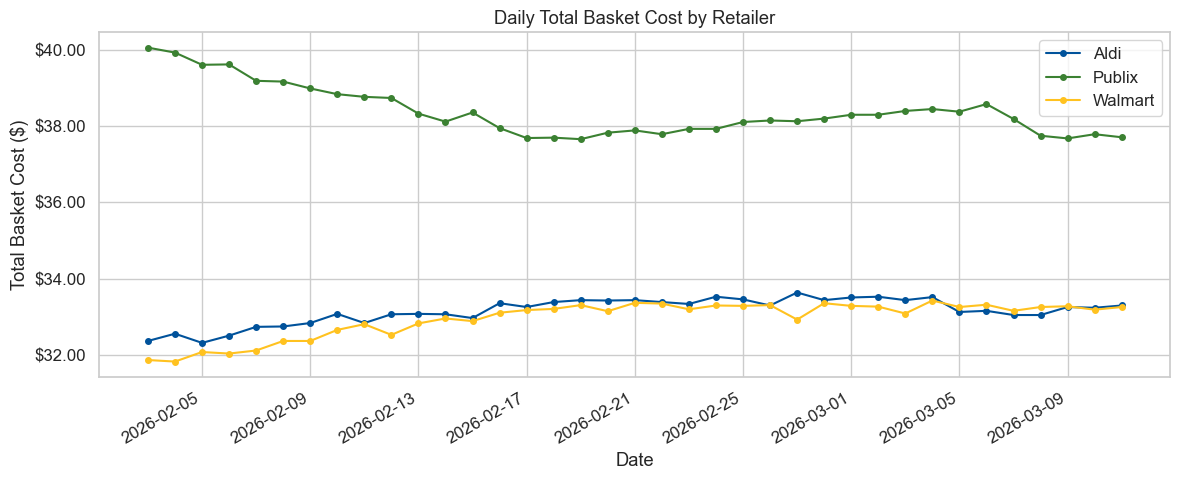

In [6]:
basket = df.groupby(["date", "store"])["clean_price"].sum().reset_index()
basket.columns = ["date", "store", "basket_cost"]

fig, ax = plt.subplots(figsize=(12, 5))
for store in basket["store"].unique():
    grp = basket[basket["store"] == store]
    ax.plot(grp["date"], grp["basket_cost"], marker="o", ms=4, label=store,
            color=STORE_COLORS.get(store, None), linewidth=1.5)
ax.set_title("Daily Total Basket Cost by Retailer")
ax.set_ylabel("Total Basket Cost ($)")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

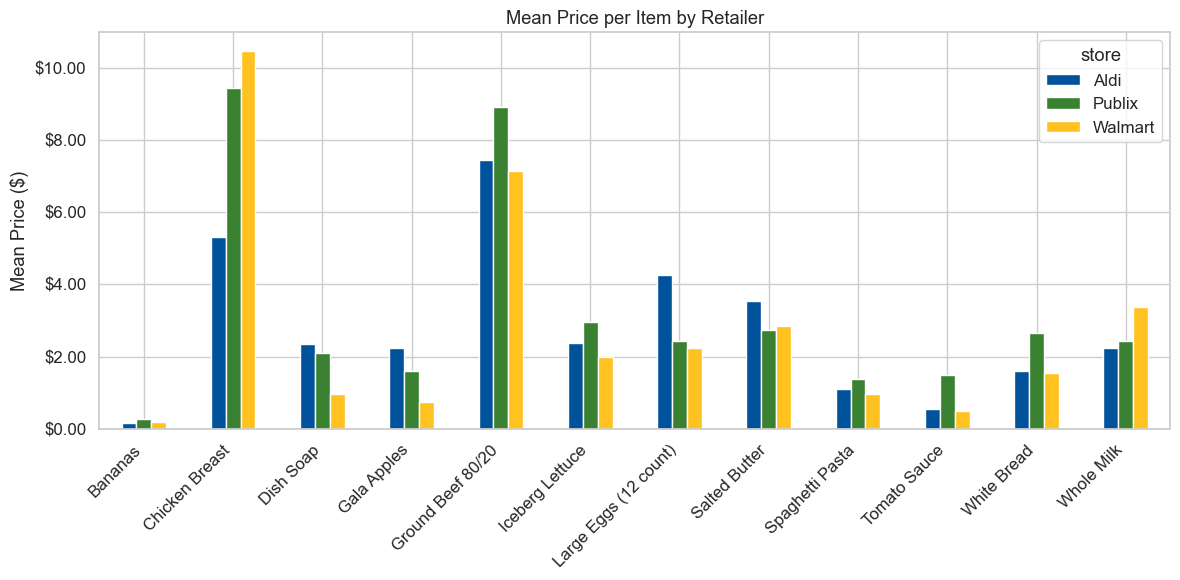

In [7]:
mean_prices = df.groupby(["search_term", "store"])["clean_price"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
mean_prices.plot(kind="bar", ax=ax, color=[STORE_COLORS[c] for c in mean_prices.columns])
ax.set_title("Mean Price per Item by Retailer")
ax.set_ylabel("Mean Price ($)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


> **Note on the “Mean Price per Item” chart**: this chart shows `clean_price` — the
> shelf price of the *matched product* — not a per-ounce or per-count rate. Products in
> the basket were chosen to be roughly comparable across stores (e.g., “Whole Milk”
> targets a one-gallon jug everywhere), but minor package-size differences may remain.
> The `price_per_unit` column is available for stricter per-ounce comparisons.

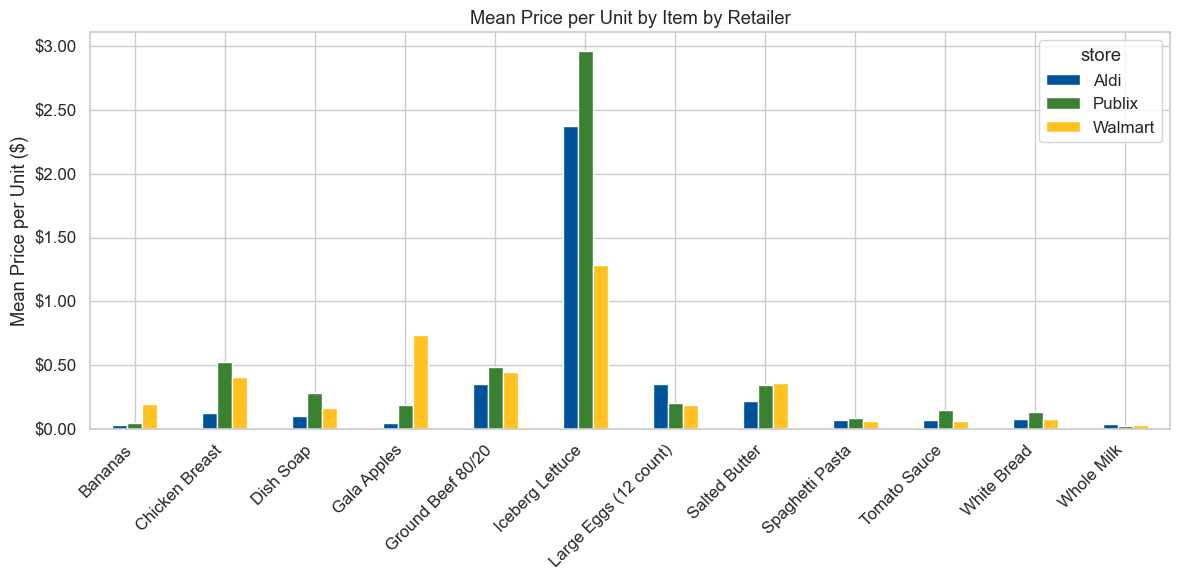

In [35]:
mean_prices = df.groupby(["search_term", "store"])["price_per_unit"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
mean_prices.plot(kind="bar", ax=ax, color=[STORE_COLORS[c] for c in mean_prices.columns])
ax.set_title("Mean Price per Unit by Item by Retailer")
ax.set_ylabel("Mean Price per Unit ($)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

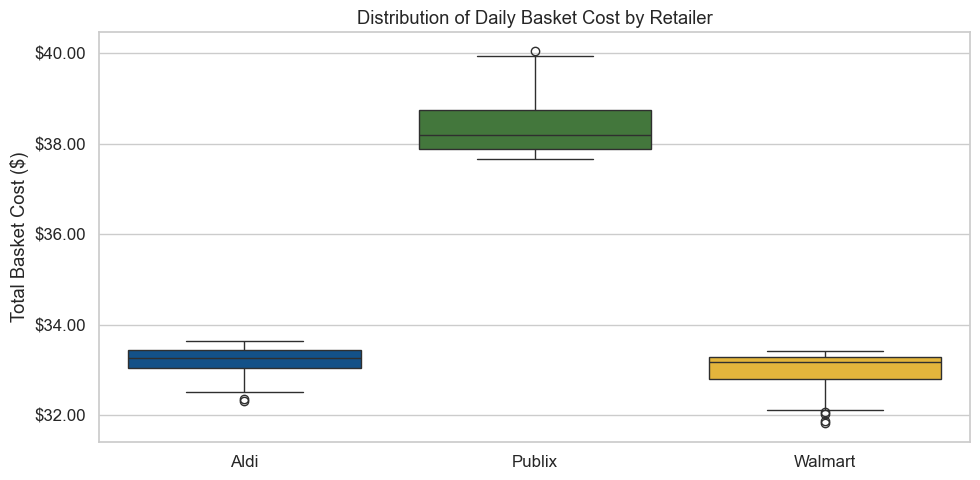

Basket cost summary statistics:


,count,mean,std,min,25%,50%,75%,max
store,,,,,,,,
Aldi,37.0000,33.1600,0.3400,32.3200,33.0500,33.2600,33.4400,33.6400
Publix,37.0000,38.3800,0.6500,37.6600,37.8900,38.2000,38.7400,40.0600
Walmart,37.0000,32.9500,0.4700,31.8300,32.8100,33.1800,33.2900,33.4300


In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=basket, x="store", y="basket_cost", palette=STORE_COLORS, ax=ax)
ax.set_title("Distribution of Daily Basket Cost by Retailer")
ax.set_ylabel("Total Basket Cost ($)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
plt.tight_layout()
plt.show()

print("Basket cost summary statistics:")
basket.groupby("store")["basket_cost"].describe().round(2)

---
## 3. RCBD Analysis — Retailer Effect on Item Prices

We treat each **item (search term)** as a block and **retailer** as the treatment
in a Randomized Complete Block Design. Items are the natural blocking variable
because they introduce the largest source of nuisance variation in the data —
Chicken Breast costs roughly 30x more than Bananas, and that variation has nothing
to do with which store is cheaper. Blocking on items removes this noise and
isolates the retailer effect.

For each item × store cell we compute the **mean price across all observation
dates**, yielding a 12 × 3 matrix (12 items, 3 retailers). The Friedman test
then asks: *"For each item, rank the three stores by price. Are those rankings
consistent enough across items to conclude that stores differ systematically?"*

### 3a. Assumption Checks
Before choosing between a parametric F-test and the non-parametric Friedman test,
we check the RCBD residuals for normality (Shapiro-Wilk) and the store columns
for equal variance (Levene's).

In [37]:
# Build the RCBD matrix: mean price per item (block) × store (treatment).
# Each cell averages across all observation dates.
rcbd = df.groupby(["search_term", "store"])["clean_price"].mean().unstack()
rcbd.columns.name = None

print(f"RCBD matrix: {rcbd.shape[0]} items × {rcbd.shape[1]} stores")
print(f"(Each cell = mean price across {df['date'].nunique()} dates)\n")
rcbd.round(2)

RCBD matrix: 12 items × 3 stores
(Each cell = mean price across 37 dates)



,Aldi,Publix,Walmart
search_term,,,
Bananas,0.1600,0.2900,0.2000
Chicken Breast,5.3200,9.4300,10.4700
Dish Soap,2.3500,2.0900,0.9600
Gala Apples,2.2500,1.5900,0.7300
Ground Beef 80/20,7.4400,8.9100,7.1400
Iceberg Lettuce,2.3700,2.9600,1.9800
Large Eggs (12 count),4.2500,2.4400,2.2300
Salted Butter,3.5300,2.7400,2.8600
Spaghetti Pasta,1.0900,1.3700,0.9800


In [38]:
# --- Assumption Check 1: Normality of RCBD residuals (Shapiro-Wilk) ---
# Residual = observed - row_mean(item) - col_mean(store) + grand_mean
grand_mean = rcbd.values.mean()
row_means = rcbd.mean(axis=1).values   # item means
col_means = rcbd.mean(axis=0).values   # store means

residuals = (
    rcbd.values
    - row_means[:, None]
    - col_means[None, :]
    + grand_mean
)

shapiro_stat, shapiro_p = stats.shapiro(residuals.flatten())
print(f"Shapiro-Wilk test on RCBD residuals: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
if shapiro_p < ALPHA:
    print("  \u2192 Residuals are NOT normally distributed (p < 0.05). Consider non-parametric test.")
else:
    print("  \u2192 Residuals appear normally distributed (fail to reject H0).")

Shapiro-Wilk test on RCBD residuals: W=0.8832, p=0.0012
  → Residuals are NOT normally distributed (p < 0.05). Consider non-parametric test.


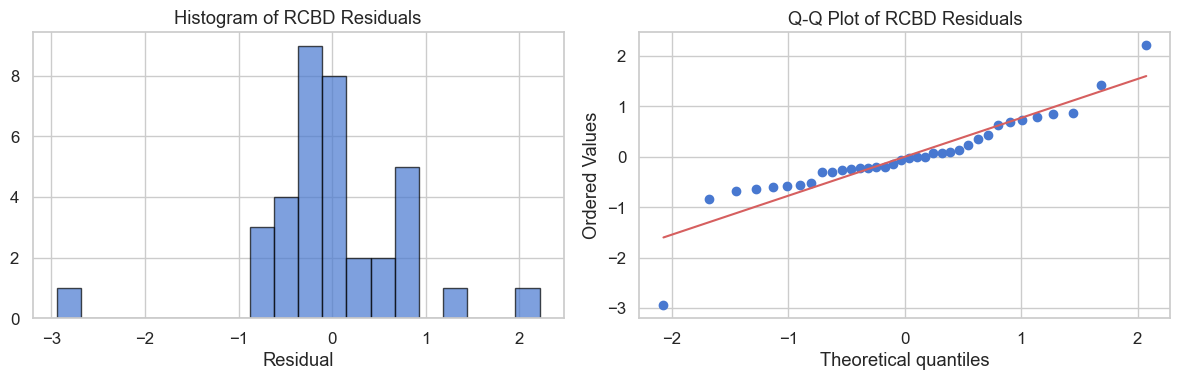

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals.flatten(), bins=20, edgecolor="black", alpha=0.7)
axes[0].set_title("Histogram of RCBD Residuals")
axes[0].set_xlabel("Residual")

stats.probplot(residuals.flatten(), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of RCBD Residuals")

plt.tight_layout()
plt.show()

#### Interpreting the Assumption Diagnostics

With only 12 blocks (items) and 3 treatments (stores), the residual sample is
small (n = 36). The Q-Q plot may show departures from normality driven by items
with large inter-store price gaps (e.g., Chicken Breast, Ground Beef) whose
residuals stretch the distribution's tails.

If either normality or equal-variance assumptions are violated, we proceed with
the **Friedman Rank Sum Test** — a non-parametric alternative that ranks stores
within each item block and does not require Gaussian residuals.

In [40]:
# --- Assumption Check 2: Homogeneity of variance (Levene's test) ---
groups = [rcbd[s].values for s in stores]
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's test for equal variances: F={levene_stat:.4f}, p={levene_p:.4e}")
if levene_p < ALPHA:
    print("  \u2192 Variances are NOT equal across stores (p < 0.05).")
else:
    print("  \u2192 Variances appear equal (fail to reject H0).")

Levene's test for equal variances: F=0.1440, p=8.6641e-01
  → Variances appear equal (fail to reject H0).


In [41]:
# --- Friedman Rank Sum Test on item × store RCBD matrix ---
assumptions_met = (shapiro_p >= ALPHA) and (levene_p >= ALPHA)

if assumptions_met:
    print("Assumptions met — running parametric F-test (one-way ANOVA on blocks).")
    f_stat, anova_p = stats.f_oneway(*groups)
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  p-value:     {anova_p:.6f}")
else:
    print("Assumptions violated — running Friedman Rank Sum Test (non-parametric).\n")

friedman_stat, friedman_p = stats.friedmanchisquare(*groups)
print(f"Friedman test: chi2={friedman_stat:.4f}, p={friedman_p:.6f}")
print(f"  Blocks: {rcbd.shape[0]} items, Treatments: {rcbd.shape[1]} stores")

if friedman_p < ALPHA:
    print(f"  \u2192 Significant difference between retailers (p < {ALPHA}).")
    print("  Store rankings are consistent enough across items to reject the null.")
else:
    print(f"  \u2192 No significant difference detected (p >= {ALPHA}).")

Assumptions violated — running Friedman Rank Sum Test (non-parametric).

Friedman test: chi2=5.1667, p=0.075522
  Blocks: 12 items, Treatments: 3 stores
  → No significant difference detected (p >= 0.05).


In [ ]:
# --- Post-hoc pairwise Wilcoxon signed-rank tests with ---
# Each pair compares 12 matched item-level mean prices between two stores.
print("Post-hoc pairwise Wilcoxon signed-rank tests:\n")
pairs = list(combinations(stores, 2))
n_comparisons = len(pairs)

posthoc_results = []
for s1, s2 in pairs:
    stat, p = stats.wilcoxon(rcbd[s1], rcbd[s2])
    sig = "*" if p < ALPHA else "ns"
    mean_diff = rcbd[s1].mean() - rcbd[s2].mean()
    wins_s1 = int((rcbd[s1] < rcbd[s2]).sum())
    wins_s2 = int((rcbd[s2] < rcbd[s1]).sum())
    posthoc_results.append({
        "Comparison": f"{s1} vs {s2}",
        "Mean Diff ($)": round(mean_diff, 2),
        "Store A Wins": wins_s1,
        "Store B Wins": wins_s2,
        "W-statistic": round(stat, 2),
        "p": round(p, 6),
        "Significant": sig,
    })


pd.DataFrame(posthoc_results)

Post-hoc pairwise Wilcoxon signed-rank tests:



,Comparison,Mean Diff ($),Store A Wins,Store B Wins,W-statistic,p,Significant
0,Aldi vs Publix,-0.4400,8,4,27.0000,0.3804,ns
1,Aldi vs Walmart,0.0200,3,9,21.0000,0.1763,ns
2,Publix vs Walmart,0.4500,3,9,17.0000,0.0923,ns


---
## 4. Category Interaction — Does Retailer Effect Vary by Category?

We test whether the retailer price advantage is consistent across product categories
(Produce, Meat, Dairy, Pantry, Household) using a two-way analysis.

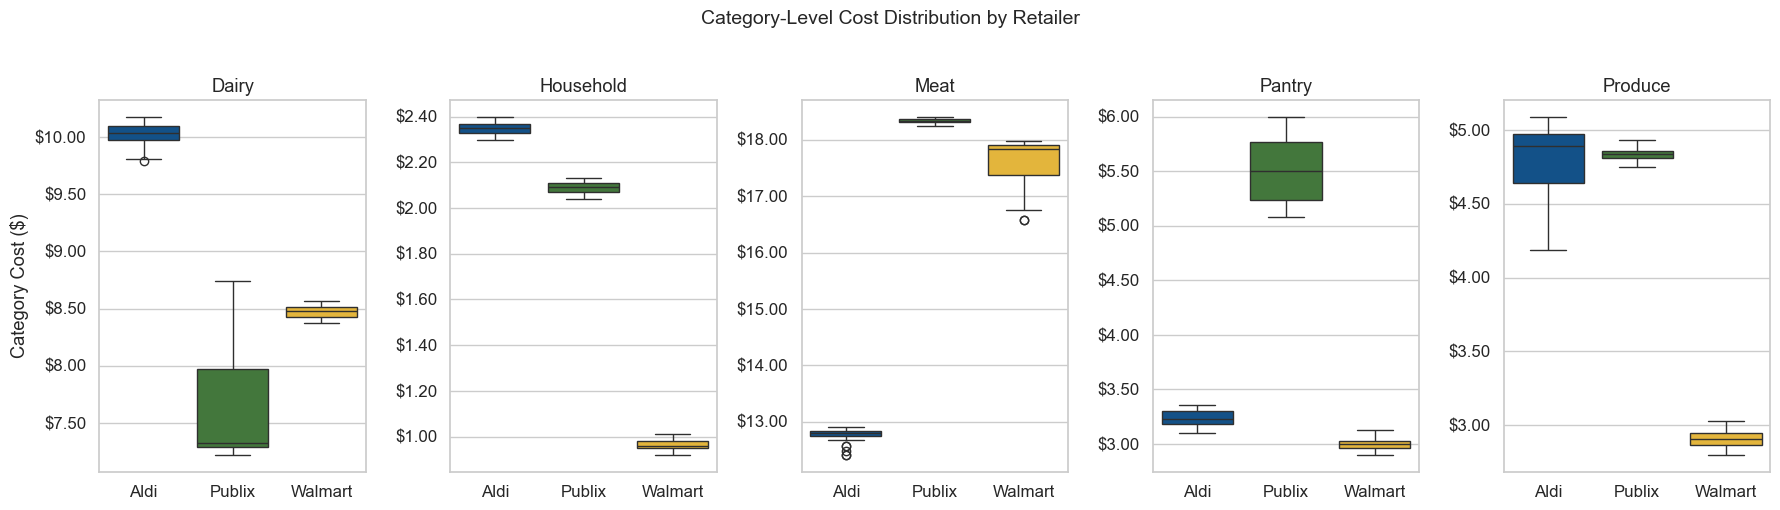

In [43]:
cat_store = df.groupby(["date", "category", "store"])["clean_price"].sum().reset_index()

fig, axes = plt.subplots(1, df["category"].nunique(), figsize=(18, 5), sharey=False)
for ax, (cat, grp) in zip(axes, cat_store.groupby("category")):
    sns.boxplot(data=grp, x="store", y="clean_price", palette=STORE_COLORS, ax=ax)
    ax.set_title(cat)
    ax.set_xlabel("")
    ax.set_ylabel("Category Cost ($)" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
plt.suptitle("Category-Level Cost Distribution by Retailer", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [44]:
# Friedman test within each category
print("Friedman test per category (store effect within each category):\n")
cat_results = []
for cat in sorted(df["category"].unique()):
    sub = cat_store[cat_store["category"] == cat].pivot(
        index="date", columns="store", values="clean_price"
    ).dropna()
    if len(sub) < 5:
        continue
    grps = [sub[s].values for s in stores]
    chi2, p = stats.friedmanchisquare(*grps)
    cat_results.append({
        "Category": cat,
        "n (dates)": len(sub),
        "Friedman chi2": round(chi2, 3),
        "p-value": round(p, 6),
        "Significant": "*" if p < ALPHA else "ns",
    })

pd.DataFrame(cat_results)

Friedman test per category (store effect within each category):



,Category,n (dates),Friedman chi2,p-value,Significant
0,Dairy,37,68.4860,0.0000,*
1,Household,37,74.0000,0.0000,*
2,Meat,37,74.0000,0.0000,*
3,Pantry,37,74.0000,0.0000,*
4,Produce,37,56.1620,0.0000,*


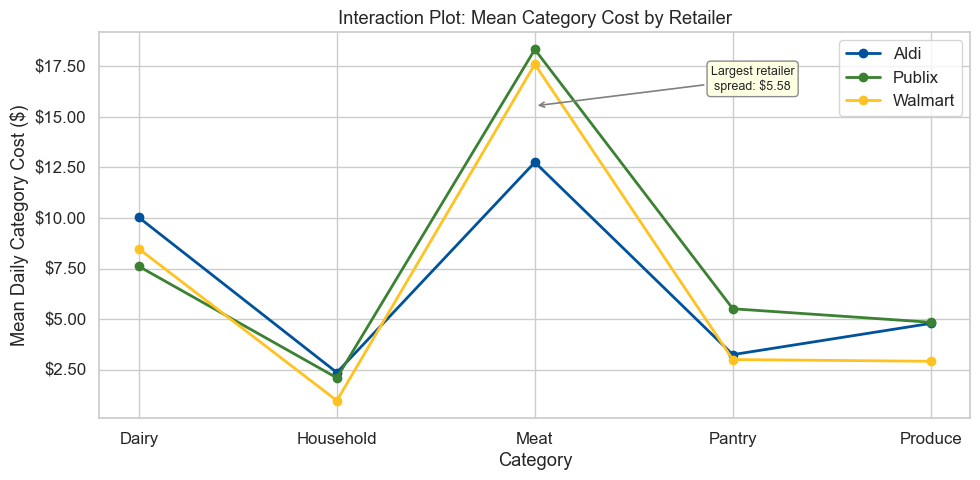

In [45]:
# Interaction plot: mean category cost by store (annotated)
interaction = cat_store.groupby(["category", "store"])["clean_price"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for store in stores:
    sub = interaction[interaction["store"] == store]
    ax.plot(sub["category"], sub["clean_price"], marker="o", label=store,
            color=STORE_COLORS[store], linewidth=2)
ax.set_title("Interaction Plot: Mean Category Cost by Retailer")
ax.set_ylabel("Mean Daily Category Cost ($)")
ax.set_xlabel("Category")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
ax.legend()

# Annotate the largest retailer divergence
meat_data = interaction[interaction["category"] == "Meat"]
if not meat_data.empty:
    meat_max = meat_data.loc[meat_data["clean_price"].idxmax()]
    meat_min = meat_data.loc[meat_data["clean_price"].idxmin()]
    mid_y = (meat_max["clean_price"] + meat_min["clean_price"]) / 2
    spread = meat_max["clean_price"] - meat_min["clean_price"]
    ax.annotate(
        f"Largest retailer\nspread: ${spread:.2f}",
        xy=("Meat", mid_y), xytext=(0.75, 0.85),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.2),
        fontsize=9, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.9),
    )

plt.tight_layout()
plt.show()

---
## 5. Price Volatility Analysis

Quantify price volatility using the **Coefficient of Variation (CV)** — the ratio of
standard deviation to mean — which allows comparison across items with very different
price levels.

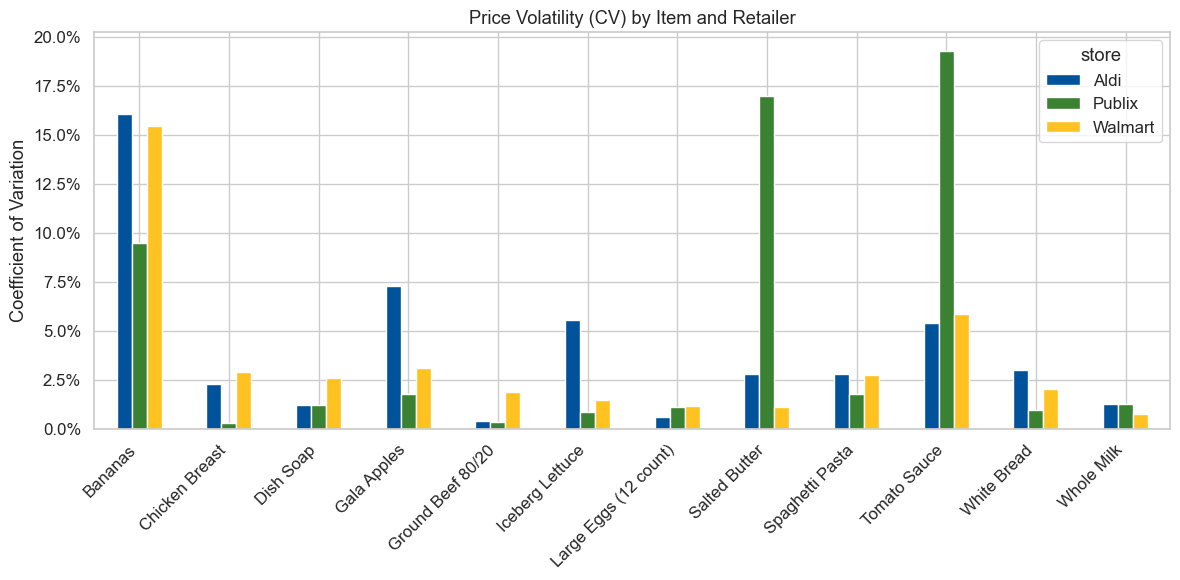

In [19]:
# CV by item × store
cv = df.groupby(["search_term", "store"])["clean_price"].agg(["mean", "std"]).reset_index()
cv["cv"] = cv["std"] / cv["mean"]
cv_pivot = cv.pivot(index="search_term", columns="store", values="cv")

fig, ax = plt.subplots(figsize=(12, 6))
cv_pivot.plot(kind="bar", ax=ax, color=[STORE_COLORS[c] for c in cv_pivot.columns])
ax.set_title("Price Volatility (CV) by Item and Retailer")
ax.set_ylabel("Coefficient of Variation")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
# Overall volatility by retailer
store_cv = df.groupby("store")["clean_price"].agg(["mean", "std"])
store_cv["cv"] = store_cv["std"] / store_cv["mean"]
print("Overall price CV by retailer:")
print(store_cv[["cv"]].sort_values("cv", ascending=False).round(4))

# Volatility by category
cat_cv = df.groupby(["category", "store"])["clean_price"].agg(["mean", "std"]).reset_index()
cat_cv["cv"] = cat_cv["std"] / cat_cv["mean"]
print("\nPrice CV by category and store:")
print(cat_cv.pivot(index="category", columns="store", values="cv").round(4))

Overall price CV by retailer:
            cv
store         
Walmart 1.0720
Publix  0.8668
Aldi    0.7239

Price CV by category and store:
store       Aldi  Publix  Walmart
category                         
Dairy     0.2500  0.1198   0.1682
Household 0.0119  0.0122   0.0261
Meat      0.1673  0.0286   0.1917
Pantry    0.3944  0.3289   0.4325
Produce   0.6424  0.6809   0.7745


---
## 6. Day-of-Week Effect

We test whether certain days of the week tend to have lower basket costs
using the Kruskal-Wallis H-test (non-parametric one-way ANOVA).

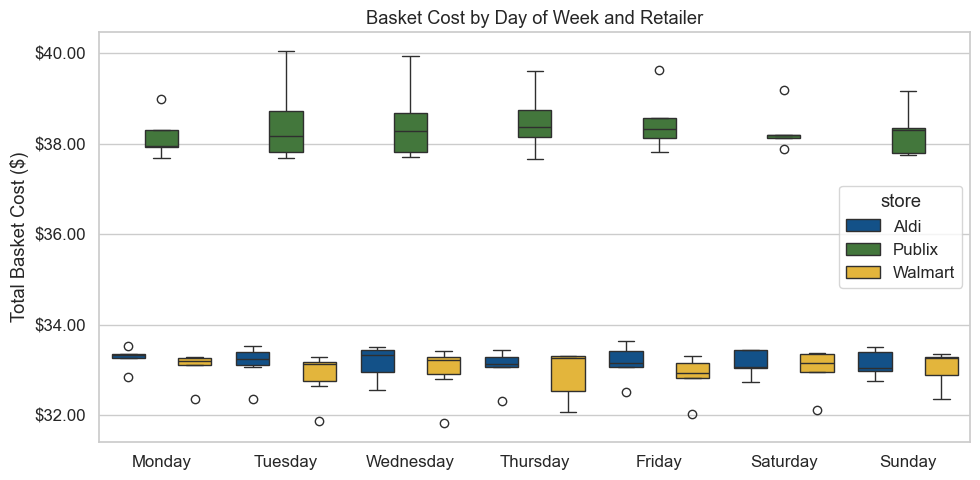

In [22]:
basket_dow = basket.copy()
basket_dow["day_of_week"] = basket_dow["date"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
basket_dow["day_of_week"] = pd.Categorical(basket_dow["day_of_week"], categories=day_order, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=basket_dow, x="day_of_week", y="basket_cost", hue="store",
            palette=STORE_COLORS, ax=ax)
ax.set_title("Basket Cost by Day of Week and Retailer")
ax.set_ylabel("Total Basket Cost ($)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
plt.tight_layout()
plt.show()

In [23]:
# Kruskal-Wallis test: does day of week affect basket cost (pooled across stores)?
day_groups = [grp["basket_cost"].values for _, grp in basket_dow.groupby("day_of_week", observed=True)]
kw_stat, kw_p = stats.kruskal(*day_groups)
print(f"Kruskal-Wallis test (day-of-week effect on basket cost):")
print(f"  H-statistic: {kw_stat:.4f}")
print(f"  p-value:     {kw_p:.6f}")
if kw_p < ALPHA:
    print(f"  → Significant day-of-week effect detected (p < {ALPHA}).")
else:
    print(f"  → No significant day-of-week effect (p >= {ALPHA}).")

# Per-store breakdown
print("\nPer-store Kruskal-Wallis tests:")
for store in stores:
    sub = basket_dow[basket_dow["store"] == store]
    dg = [g["basket_cost"].values for _, g in sub.groupby("day_of_week", observed=True)]
    if len(dg) >= 2 and all(len(g) >= 2 for g in dg):
        h, p = stats.kruskal(*dg)
        sig = "*" if p < ALPHA else "ns"
        print(f"  {store:>8}: H={h:.3f}, p={p:.4f} {sig}")

Kruskal-Wallis test (day-of-week effect on basket cost):
  H-statistic: 0.2270
  p-value:     0.999776
  → No significant day-of-week effect (p >= 0.05).

Per-store Kruskal-Wallis tests:
      Aldi: H=1.260, p=0.9738 ns
    Publix: H=1.047, p=0.9837 ns
   Walmart: H=1.695, p=0.9455 ns


---
## 7. Multi-Store Optimization

Can a consumer save money by cherry-picking the cheapest item from each store,
rather than shopping at a single retailer?

In [27]:
# For each date × item, find the cheapest store
cheapest = df.loc[df.groupby(["date", "search_term"])["clean_price"].idxmin()]
optimal_basket = cheapest.groupby("date")["clean_price"].sum().reset_index()
optimal_basket.columns = ["date", "optimal_cost"]

comparison = basket.pivot(index="date", columns="store", values="basket_cost").reset_index()
comparison = comparison.merge(optimal_basket, on="date")

for store in stores:
    comparison[f"savings_vs_{store}"] = comparison[store] - comparison["optimal_cost"]

comparison["best_single_store"] = comparison[stores].min(axis=1)
comparison["split_savings"] = comparison["best_single_store"] - comparison["optimal_cost"]

print("Multi-store optimization summary:")
print(f"  Mean optimal (split) basket cost:    ${comparison['optimal_cost'].mean():.2f}")
for s in stores:
    print(f"  Mean {s} basket cost:{'':>{14-len(s)}} ${comparison[s].mean():.2f}")
print(f"\n  Mean additional savings from splitting vs. best single store: "
      f"${comparison['split_savings'].mean():.2f}/day")
print(f"  Max single-day split savings: ${comparison['split_savings'].max():.2f}")

Multi-store optimization summary:
  Mean optimal (split) basket cost:    $26.35
  Mean Aldi basket cost:           $33.16
  Mean Publix basket cost:         $38.38
  Mean Walmart basket cost:        $32.95

  Mean additional savings from splitting vs. best single store: $6.59/day
  Max single-day split savings: $7.12


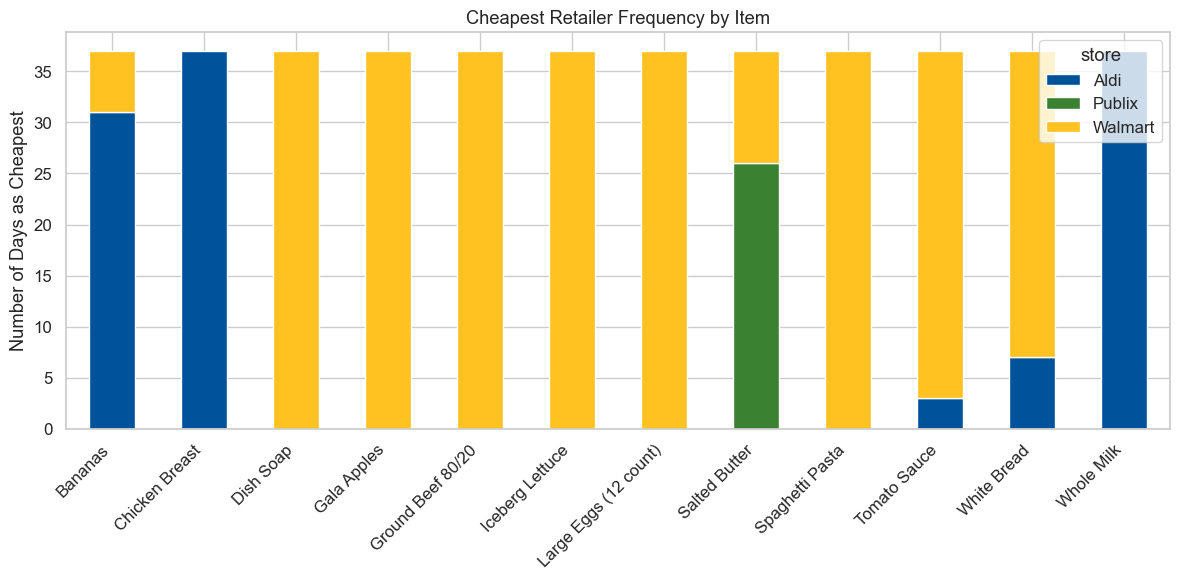

In [28]:
# Which store wins each item most often?
win_counts = cheapest.groupby(["search_term", "store"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
win_counts.plot(kind="bar", stacked=True, ax=ax,
                color=[STORE_COLORS[c] for c in win_counts.columns])
ax.set_title("Cheapest Retailer Frequency by Item")
ax.set_ylabel("Number of Days as Cheapest")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

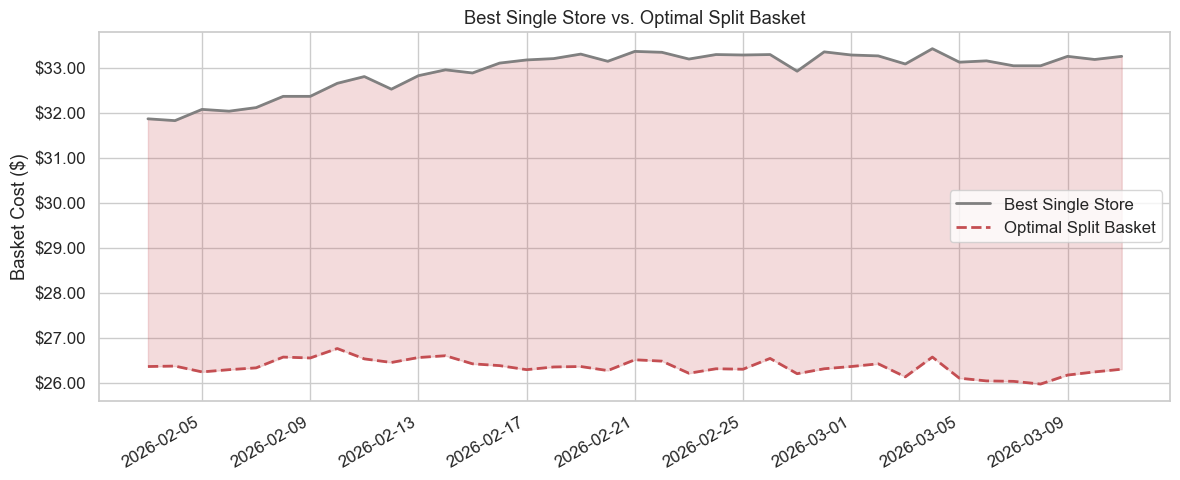

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(comparison["date"], comparison["best_single_store"], label="Best Single Store",
        linewidth=2, color="gray")
ax.plot(comparison["date"], comparison["optimal_cost"], label="Optimal Split Basket",
        linewidth=2, linestyle="--", color="#C44E52")
ax.fill_between(comparison["date"], comparison["optimal_cost"],
                comparison["best_single_store"], alpha=0.2, color="#C44E52")
ax.set_title("Best Single Store vs. Optimal Split Basket")
ax.set_ylabel("Basket Cost ($)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 8. Summary of Findings

SUMMARY OF STATISTICAL FINDINGS

1. RETAILER EFFECT ON ITEM PRICES (RCBD: items as blocks)
   Friedman test: chi2=5.17, p=0.075522
   → The difference between retailers is NOT significant at α=0.05.
   Mean item price by store (across 12 items):
     Aldi: $2.76/item  |  basket: $33.16/day
     Publix: $3.20/item  |  basket: $38.38/day
     Walmart: $2.75/item  |  basket: $32.95/day

2. CATEGORY INTERACTION
   Dairy: Friedman p=0.0000 (significant)
   Household: Friedman p=0.0000 (significant)
   Meat: Friedman p=0.0000 (significant)
   Pantry: Friedman p=0.0000 (significant)
   Produce: Friedman p=0.0000 (significant)

3. PRICE VOLATILITY
   Most volatile item:  Bananas (CV = 13.6%)
   Least volatile item: Ground Beef 80/20 (CV = 0.9%)
   Produce items show highest noise due to unit-weight variability;
   Pantry items are the most price-stable.

4. DAY-OF-WEEK EFFECT
   Kruskal-Wallis: H=0.23, p=0.9998
   → Day-of-week effect is NOT significant at α=0.05.
   Prices do not vary systema

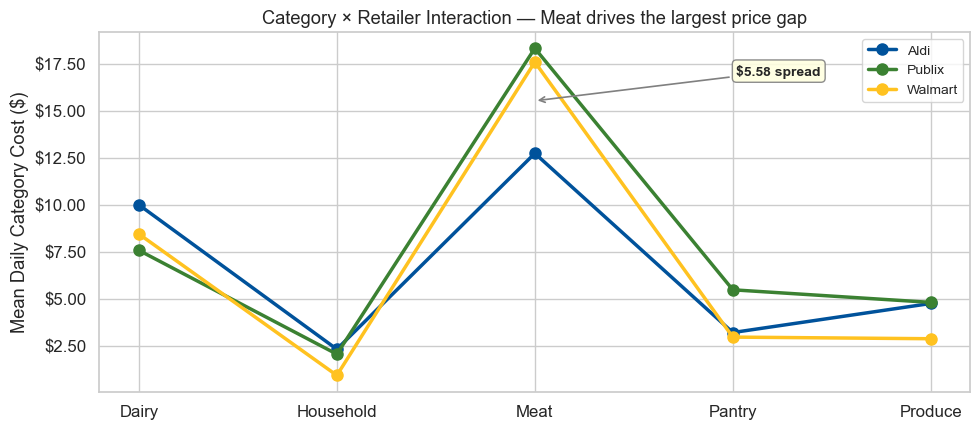

In [52]:
print("=" * 70)
print("SUMMARY OF STATISTICAL FINDINGS")
print("=" * 70)

print("\n1. RETAILER EFFECT ON ITEM PRICES (RCBD: items as blocks)")
print(f"   Friedman test: chi2={friedman_stat:.2f}, p={friedman_p:.6f}")
sig_str = "SIGNIFICANT" if friedman_p < ALPHA else "NOT significant"
print(f"   \u2192 The difference between retailers is {sig_str} at \u03b1={ALPHA}.")
print(f"   Mean item price by store (across 12 items):")
for s in stores:
    print(f"     {s}: ${rcbd[s].mean():.2f}/item  |  basket: ${basket[basket['store']==s]['basket_cost'].mean():.2f}/day")

print("\n2. CATEGORY INTERACTION")
for r in cat_results:
    status = "significant" if r["Significant"] == "*" else "not significant"
    print(f"   {r['Category']}: Friedman p={r['p-value']:.4f} ({status})")

print("\n3. PRICE VOLATILITY")
most_volatile = cv.groupby("search_term")["cv"].mean().sort_values(ascending=False)
print(f"   Most volatile item:  {most_volatile.index[0]} (CV = {most_volatile.iloc[0]:.1%})")
print(f"   Least volatile item: {most_volatile.index[-1]} (CV = {most_volatile.iloc[-1]:.1%})")
print("   Produce items show highest noise due to unit-weight variability;")
print("   Pantry items are the most price-stable.")

print("\n4. DAY-OF-WEEK EFFECT")
print(f"   Kruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.4f}")
dow_str = "SIGNIFICANT" if kw_p < ALPHA else "NOT significant"
print(f"   \u2192 Day-of-week effect is {dow_str} at \u03b1={ALPHA}.")
print("   Prices do not vary systematically by day across any store.")

print("\n5. MULTI-STORE OPTIMIZATION")
print(f"   Avg savings from split shopping vs best single store: "
      f"${comparison['split_savings'].mean():.2f}/day")

print("\n" + "=" * 70)

# --- Hero visualization: Interaction Plot (simplified for summary) ---
print("\nKey Visualization: Where do retailers diverge most?\n")
interaction_s = cat_store.groupby(["category", "store"])["clean_price"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
for store in stores:
    sub = interaction_s[interaction_s["store"] == store]
    ax.plot(sub["category"], sub["clean_price"], marker="o", label=store,
            color=STORE_COLORS[store], linewidth=2.5, markersize=8)
ax.set_ylabel("Mean Daily Category Cost ($)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
ax.legend(fontsize=10)
ax.set_title("Category \u00d7 Retailer Interaction \u2014 Meat drives the largest price gap")

meat = interaction_s[interaction_s["category"] == "Meat"]
if not meat.empty:
    top = meat.loc[meat["clean_price"].idxmax()]
    bot = meat.loc[meat["clean_price"].idxmin()]
    spread = top["clean_price"] - bot["clean_price"]
    mid = (top["clean_price"] + bot["clean_price"]) / 2
    ax.annotate(
        f"${spread:.2f} spread",
        xy=("Meat", mid), xytext=(0.78, 0.88),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.2),
        fontsize=10, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.9),
    )
plt.tight_layout()
plt.show()